In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/__results__.html
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/__notebook__.ipynb
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/__output__.json
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/custom.css
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/preprocessing_outputs/preprocessing_config.json
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/preprocessing_outputs/train_split.csv
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/preprocessing_outputs/test_split.csv
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/preprocessing_outputs/internal_validation_split.csv
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/preprocessing_outputs/class_names.json
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/__results___files/__results___30_0.png
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/__results___files/__results___29_0.png
/kaggle

# MaleVis Generalized CNN

This notebook develops a generalized CNN model for 25-class malware image classification using the cleaned MaleVis dataset.

The dataset splits were prepared beforehand:
- Training split for model learning
- Internal validation split for model selection and tuning
- Final test split for unbiased final evaluation

In [2]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Reproducibility

In [3]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
gpus = tf.config.list_physical_devices("GPU")

print("Available GPUs:", gpus)

if gpus:
    print("GPU is available.")
else:
    print("GPU not detected. Check Kaggle accelerator settings.")

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU is available.


## 2. Configuration

In [8]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32
NUM_CLASSES = 25

INITIAL_LEARNING_RATE = 0.0005
MAX_EPOCHS = 30

AUTOTUNE = tf.data.AUTOTUNE

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Learning rate:", INITIAL_LEARNING_RATE)
print("Maximum epochs:", MAX_EPOCHS)

Image size: (224, 224)
Batch size: 32
Number of classes: 25
Learning rate: 0.0005
Maximum epochs: 30


In [9]:
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file in [
            "train_split.csv",
            "internal_validation_split.csv",
            "test_split.csv",
            "class_names.json",
            "preprocessing_config.json"
        ]:
            print(os.path.join(root, file))

/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/preprocessing_outputs/preprocessing_config.json
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/preprocessing_outputs/train_split.csv
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/preprocessing_outputs/test_split.csv
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/preprocessing_outputs/internal_validation_split.csv
/kaggle/input/notebooks/sadiaafrin1234/notebook1817f3396e/preprocessing_outputs/class_names.json


In [10]:
png_folders = set()

for root, dirs, files in os.walk("/kaggle/input"):
    if any(
        file.lower().endswith(".png")
        for file in files
    ):
        png_folders.add(root)

for folder in sorted(png_folders):
    print(folder)

/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Adposhel
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Agent
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Allaple
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Amonetize
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Androm
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Autorun
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/BrowseFox
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Dinwod
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Elex
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Expiro
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_t

In [11]:
PROCESSED_DIR = Path(
    "/kaggle/input/notebooks/sadiaafrin1234/"
    "notebook1817f3396e/preprocessing_outputs"
)

TRAIN_CSV = PROCESSED_DIR / "train_split.csv"
INTERNAL_VAL_CSV = PROCESSED_DIR / "internal_validation_split.csv"
TEST_CSV = PROCESSED_DIR / "test_split.csv"

CLASS_NAMES_FILE = PROCESSED_DIR / "class_names.json"
CONFIG_FILE = PROCESSED_DIR / "preprocessing_config.json"

In [12]:
required_files = [
    TRAIN_CSV,
    INTERNAL_VAL_CSV,
    TEST_CSV,
    CLASS_NAMES_FILE,
    CONFIG_FILE
]

for file_path in required_files:
    print(
        file_path.name,
        "->",
        "Found" if file_path.exists() else "Missing"
    )

assert all(
    file_path.exists()
    for file_path in required_files
)

print("All preprocessing files verified.")

train_split.csv -> Found
internal_validation_split.csv -> Found
test_split.csv -> Found
class_names.json -> Found
preprocessing_config.json -> Found
All preprocessing files verified.


## 3. Load Clean Dataset Splits

In [13]:
with open(CLASS_NAMES_FILE, "r") as file:
    class_names = json.load(file)

print("Number of classes:", len(class_names))
print(class_names)

assert len(class_names) == NUM_CLASSES

Number of classes: 25
['Adposhel', 'Agent', 'Allaple', 'Amonetize', 'Androm', 'Autorun', 'BrowseFox', 'Dinwod', 'Elex', 'Expiro', 'Fasong', 'HackKMS', 'Hlux', 'Injector', 'InstallCore', 'MultiPlug', 'Neoreklami', 'Neshta', 'Regrun', 'Sality', 'Snarasite', 'Stantinko', 'VBA', 'VBKrypt', 'Vilsel']


In [14]:
train_df = pd.read_csv(TRAIN_CSV)
internal_val_df = pd.read_csv(INTERNAL_VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training samples:", len(train_df))
print("Internal validation samples:", len(internal_val_df))
print("Final test samples:", len(test_df))

Training samples: 6999
Internal validation samples: 1751
Final test samples: 3477


In [15]:
display(train_df.head())
display(internal_val_df.head())
display(test_df.head())

,filepath,relative_path,class_name,label,label_id,hash
0,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/490414f8e646fbad11d392106f38ec9...,Adposhel,Adposhel,0,5eabfcd800292738bcb70f818a8b9319
1,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/96022ca14d5b070258c892ebf7153e0...,Adposhel,Adposhel,0,55951eca5fdd3aa764b096cba7e06ab9
2,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/95c6546ecaf79394a4ace0512a52057...,Adposhel,Adposhel,0,bc1bd6f2cd6125334409930bba59d7a3
3,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/774964c435f7b10f3227fceebfad605...,Adposhel,Adposhel,0,66ad26b2bd35d5017c54210bcc0e03e1
4,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/91a0467c07dbb3282e07dc0a214846a...,Adposhel,Adposhel,0,c7baaebfdcf4ca3c1561105727feefb1


,filepath,relative_path,class_name,label,label_id,hash
0,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/5e3b9cca64ff8f0eaad8f67c511e0a6...,Adposhel,Adposhel,0,03dbf87fc916a2a0dfd177ba9e330278
1,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/87c470e98dffe5d9362b2e9f0650b59...,Adposhel,Adposhel,0,cf61cb8939737559fc14af9f20a501b5
2,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/4749cda8f3cece89c9e2027d9f7ca6b...,Adposhel,Adposhel,0,e6b79ff658b56887275b14cc59a7c6b9
3,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/0736917e1208c27a9cd529e8fa3d9eb...,Adposhel,Adposhel,0,60fa977472b0a0bdcaf678d255c67f65
4,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/134f26d244c263ff87f6d51cbb923a8...,Adposhel,Adposhel,0,809c9ea5c1be9fb12f8db75ce93d9b1b


,filepath,relative_path,class_name,label,label_id,hash
0,/kaggle/input/datasets/sohamkumar1703/malevis-...,val/Adposhel/fca5de1a353db8f6e9419a7eff62a97a2...,Adposhel,Adposhel,0,974ced03c9ed9989d449c80121f0c760
1,/kaggle/input/datasets/sohamkumar1703/malevis-...,val/Adposhel/d689f28a776829343d313486a8051978c...,Adposhel,Adposhel,0,adb08e8813ac62f68f3f74ab6fcaf8aa
2,/kaggle/input/datasets/sohamkumar1703/malevis-...,val/Adposhel/beca37575577184d704d450bb51661fd8...,Adposhel,Adposhel,0,bbd2f4d41402f4fc854513719a6b0cb9
3,/kaggle/input/datasets/sohamkumar1703/malevis-...,val/Adposhel/fcbe2516d817437f619a9c124c3210932...,Adposhel,Adposhel,0,f2b60393e5dd60456f9fa15d657b1611
4,/kaggle/input/datasets/sohamkumar1703/malevis-...,val/Adposhel/e97f1ef855a76027289ded7c9fe923239...,Adposhel,Adposhel,0,a0bdcfe313a98e7df3434a20de07e0fc


# Dataset Verfication

In [16]:
required_columns = {
    "filepath",
    "relative_path",
    "class_name",
    "label_id",
    "hash"
}

for split_name, dataframe in [
    ("Train", train_df),
    ("Internal Validation", internal_val_df),
    ("Test", test_df)
]:
    missing = required_columns - set(dataframe.columns)

    print(split_name, "missing columns:", missing)

    assert len(missing) == 0

print("Required columns verified.")

Train missing columns: set()
Internal Validation missing columns: set()
Test missing columns: set()
Required columns verified.


In [18]:
for dataframe in [
    train_df,
    internal_val_df,
    test_df
]:
    dataframe["label_id"] = dataframe["label_id"].astype(np.int32)

In [19]:
for split_name, dataframe in [
    ("Train", train_df),
    ("Internal Validation", internal_val_df),
    ("Test", test_df)
]:
    print(
        split_name,
        "classes:",
        dataframe["label_id"].nunique()
    )

    assert dataframe["label_id"].nunique() == NUM_CLASSES

print("All three splits contain 25 classes.")

Train classes: 25
Internal Validation classes: 25
Test classes: 25
All three splits contain 25 classes.


In [20]:
train_hashes = set(train_df["hash"].astype(str))
val_hashes = set(internal_val_df["hash"].astype(str))
test_hashes = set(test_df["hash"].astype(str))

print(
    "Train vs Validation overlap:",
    len(train_hashes & val_hashes)
)

print(
    "Train vs Test overlap:",
    len(train_hashes & test_hashes)
)

print(
    "Validation vs Test overlap:",
    len(val_hashes & test_hashes)
)

assert len(train_hashes & val_hashes) == 0
assert len(train_hashes & test_hashes) == 0
assert len(val_hashes & test_hashes) == 0

print("No cross-split hash leakage.")

Train vs Validation overlap: 0
Train vs Test overlap: 0
Validation vs Test overlap: 0
No cross-split hash leakage.


## 4. Rebuild Image Paths

In [21]:
DATASET_DIR = Path(
    "/kaggle/input/datasets/sohamkumar1703/"
    "malevis-dataset/malevis_train_val_300x300"
)

print("Dataset directory:", DATASET_DIR)
print("Exists:", DATASET_DIR.exists())

Dataset directory: /kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300
Exists: True


In [23]:
def resolve_image_path(relative_path):
    relative_path = str(relative_path).replace("\\", "/")
    relative_path = relative_path.lstrip("/")

    possible_paths = [
        DATASET_DIR / relative_path,
        DATASET_DIR / "train" / relative_path,
        DATASET_DIR / "val" / relative_path,
    ]

    for path in possible_paths:
        if path.exists():
            return str(path)

    return None

In [24]:
train_df["current_filepath"] = (
    train_df["relative_path"].apply(resolve_image_path)
)

internal_val_df["current_filepath"] = (
    internal_val_df["relative_path"].apply(resolve_image_path)
)

test_df["current_filepath"] = (
    test_df["relative_path"].apply(resolve_image_path)
)

In [25]:
for split_name, dataframe in [
    ("Train", train_df),
    ("Internal Validation", internal_val_df),
    ("Test", test_df)
]:
    missing = dataframe["current_filepath"].isnull().sum()

    print(split_name, "missing paths:", missing)

    assert missing == 0

print("All image paths resolved successfully.")

Train missing paths: 0
Internal Validation missing paths: 0
Test missing paths: 0
All image paths resolved successfully.


## 5. Class Distribution

In [26]:
train_distribution = (
    train_df
    .groupby(["label_id", "class_name"])
    .size()
    .reset_index(name="image_count")
    .sort_values("label_id")
)

display(train_distribution)

,label_id,class_name,image_count
0,0,Adposhel,280
1,1,Agent,280
2,2,Allaple,280
3,3,Amonetize,281
4,4,Androm,280
5,5,Autorun,280
6,6,BrowseFox,280
7,7,Dinwod,280
8,8,Elex,280
9,9,Expiro,280


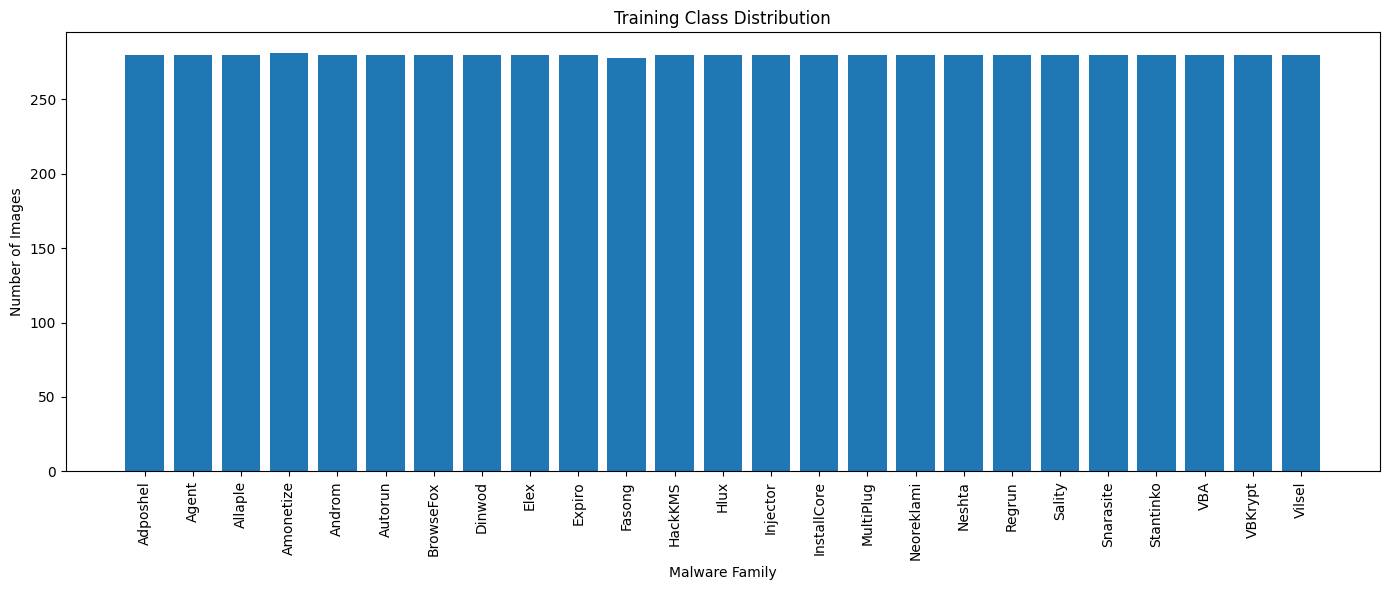

In [27]:
plt.figure(figsize=(14, 6))

plt.bar(
    train_distribution["class_name"],
    train_distribution["image_count"]
)

plt.title("Training Class Distribution")
plt.xlabel("Malware Family")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## 6. TensorFlow Data Pipeline

In [28]:
def load_and_normalize_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_png(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = image / 255.0

    return image, label

In [44]:
 data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
            factor=0.02
        ),

        tf.keras.layers.RandomZoom(
            height_factor=0.03,
            width_factor=0.03
        ),

        tf.keras.layers.RandomTranslation(
            height_factor=0.02,
            width_factor=0.02
        ),
    ],
    name="training_augmentation"
)

print("Mild training augmentation created.")

Mild training augmentation created.


In [30]:
train_paths = (
    train_df["current_filepath"]
    .astype(str)
    .to_numpy()
)

train_labels = (
    train_df["label_id"]
    .astype(np.int32)
    .to_numpy()
)

internal_val_paths = (
    internal_val_df["current_filepath"]
    .astype(str)
    .to_numpy()
)

internal_val_labels = (
    internal_val_df["label_id"]
    .astype(np.int32)
    .to_numpy()
)

test_paths = (
    test_df["current_filepath"]
    .astype(str)
    .to_numpy()
)

test_labels = (
    test_df["label_id"]
    .astype(np.int32)
    .to_numpy()
)

print("Train:", train_paths.shape, train_labels.shape)
print(
    "Internal validation:",
    internal_val_paths.shape,
    internal_val_labels.shape
)
print("Test:", test_paths.shape, test_labels.shape)

Train: (6999,) (6999,)
Internal validation: (1751,) (1751,)
Test: (3477,) (3477,)


In [31]:
def create_dataset(
    image_paths,
    labels,
    training=False
):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            image_paths,
            labels
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(image_paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_normalize_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    if training:
        dataset = dataset.map(
            lambda images, batch_labels: (
                data_augmentation(
                    images,
                    training=True
                ),
                batch_labels
            ),
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [45]:
 train_ds = create_dataset(
    train_paths,
    train_labels,
    training=True
)

internal_val_ds = create_dataset(
    internal_val_paths,
    internal_val_labels,
    training=False
)

test_ds = create_dataset(
    test_paths,
    test_labels,
    training=False
)

print("Datasets recreated successfully.")

Datasets recreated successfully.


In [33]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print(
        "Pixel min:",
        float(tf.reduce_min(images))
    )
    print(
        "Pixel max:",
        float(tf.reduce_max(images))
    )

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Pixel min: 0.0
Pixel max: 0.9999954104423523


In [34]:
for split_name, dataset in [
    ("Internal Validation", internal_val_ds),
    ("Test", test_ds)
]:
    for images, labels in dataset.take(1):
        print(
            split_name,
            "image shape:",
            images.shape
        )

        print(
            split_name,
            "label shape:",
            labels.shape
        )

Internal Validation image shape: (32, 224, 224, 3)
Internal Validation label shape: (32,)
Test image shape: (32, 224, 224, 3)
Test label shape: (32,)


## 7. Data Visualization

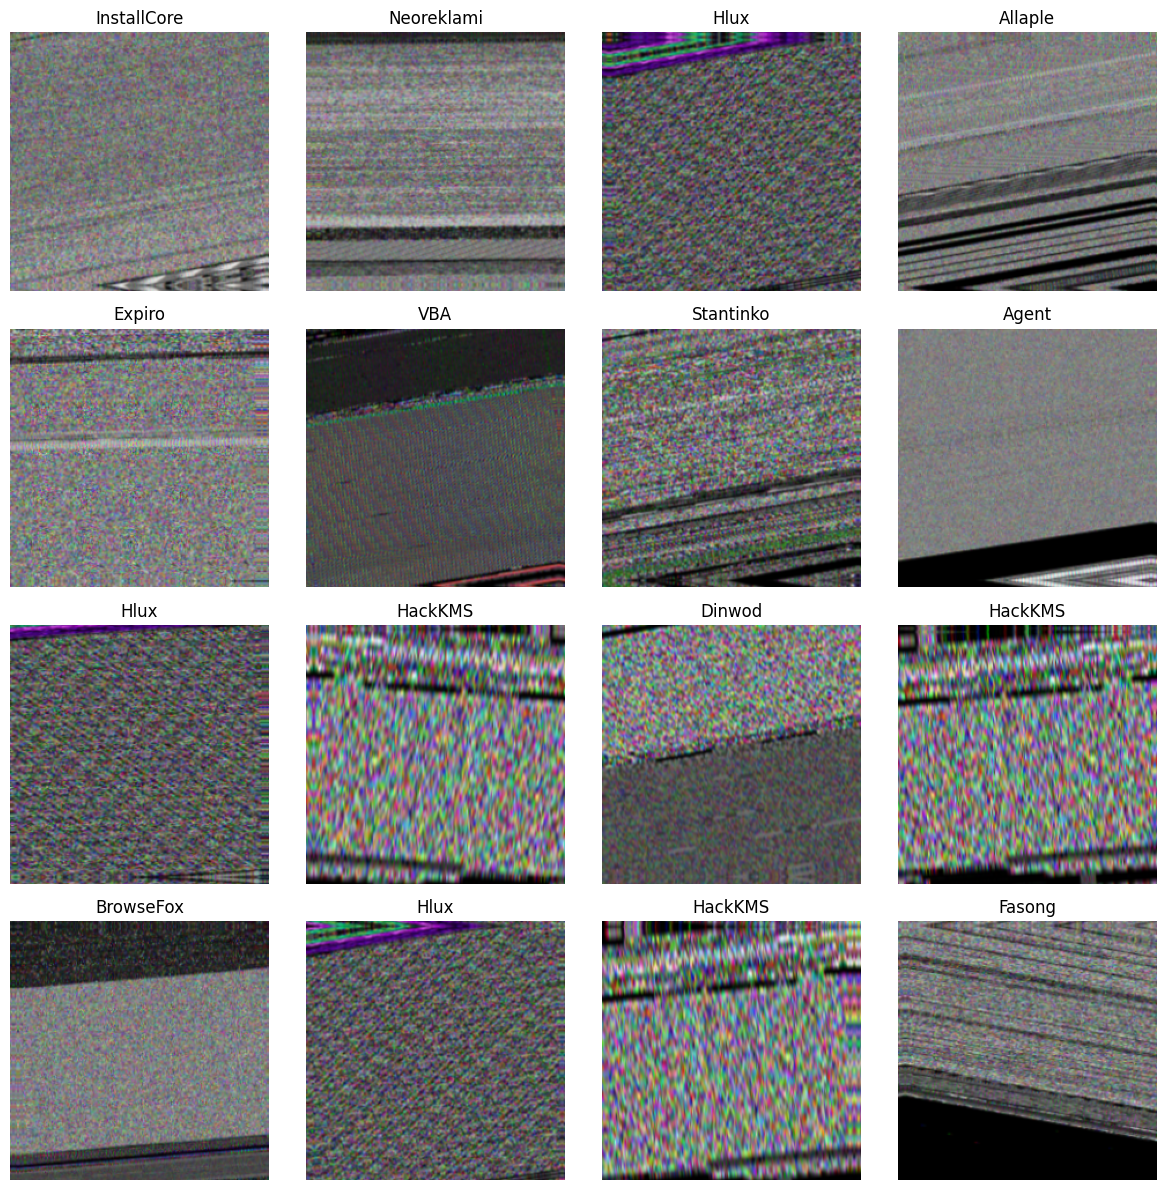

In [35]:
plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):
    for index in range(16):
        plt.subplot(
            4,
            4,
            index + 1
        )

        plt.imshow(
            images[index].numpy()
        )

        label_id = int(
            labels[index].numpy()
        )

        plt.title(
            class_names[label_id]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

 ## 8. Generalization-Focused CNN Model

The CNN uses moderate model capacity with controlled regularization.
The objective is to learn sufficiently rich malware-image features
while reducing excessive memorization of the training data.

In [56]:
 from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import Model

tf.keras.backend.clear_session()

L2_WEIGHT = 1e-5

inputs = layers.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    name="input_image"
)

# Block 1
x = layers.Conv2D(
    32,
    3,
    padding="same",
    use_bias=False,
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(inputs)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(2)(x)


# Block 2
x = layers.Conv2D(
    64,
    3,
    padding="same",
    use_bias=False,
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(2)(x)


# Block 3
x = layers.Conv2D(
    128,
    3,
    padding="same",
    use_bias=False,
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(2)(x)


# Block 4
x = layers.Conv2D(
    256,
    3,
    padding="same",
    use_bias=False,
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(2)(x)


# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(
    0.40
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="malevis_generalized_cnn"
)

print("Generalization-focused CNN created.")

Generalization-focused CNN created.


In [57]:
model.summary()

Model: "malevis_generalized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 25)             │         3,22

 Total params: 426,489 (1.63 MB)

 Trainable params: 425,273 (1.62 MB)

 Non-trainable params: 1,216 (4.75 KB)

## 9. Model Compilation

In [59]:
  INITIAL_LEARNING_RATE = 0.0005

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [67]:
 OUTPUT_DIR = Path(
    "/kaggle/working/generalized_cnn_v3_outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    OUTPUT_DIR /
    "best_generalized_cnn.keras"
)

TRAINING_LOG_PATH = (
    OUTPUT_DIR /
    "training_log.csv"
)

## 10. Training Callbacks

In [69]:
 callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(TRAINING_LOG_PATH)
    ),

    tf.keras.callbacks.TerminateOnNaN()
]

print("Callbacks configured.")

Callbacks configured.


In [70]:
 print("=" * 45)
print("Generalized CNN Configuration")
print("=" * 45)

print("Model             :", model.name)
print("Image size        :", IMG_SIZE)
print("Classes           :", NUM_CLASSES)
print("Batch size        :", BATCH_SIZE)
print("Initial LR        :", INITIAL_LEARNING_RATE)
print("Maximum epochs    :", MAX_EPOCHS)
print("L2 weight         :", L2_WEIGHT)
print("Dense dropout     :", 0.35)

print("=" * 45)

Generalized CNN Configuration
Model             : malevis_generalized_cnn
Image size        : (224, 224)
Classes           : 25
Batch size        : 32
Initial LR        : 0.0005
Maximum epochs    : 30
L2 weight         : 1e-05
Dense dropout     : 0.35


## 11. Model Training

In [71]:
 history = model.fit(
    train_ds,
    validation_data=internal_val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.3802 - loss: 2.3620
Epoch 1: val_loss improved from None to 3.81075, saving model to /kaggle/working/generalized_cnn_v3_outputs/best_generalized_cnn.keras

Epoch 1: finished saving model to /kaggle/working/generalized_cnn_v3_outputs/best_generalized_cnn.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 55s 219ms/step - accuracy: 0.5041 - loss: 1.9209 - val_accuracy: 0.0543 - val_loss: 3.8107 - learning_rate: 5.0000e-04
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.6890 - loss: 1.2352
Epoch 2: val_loss improved from 3.81075 to 2.11375, saving model to /kaggle/working/generalized_cnn_v3_outputs/best_generalized_cnn.keras

Epoch 2: finished saving model to /kaggle/working/generalized_cnn_v3_outputs/best_generalized_cnn.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 42s 188ms/step - accuracy: 0.7134 - loss: 1.1410 - val_accuracy: 0.4917 - val_loss: 2.1138 - learning_rate: 5.0000e-04
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 17

In [72]:
print("Checking internal validation stability...\n")

results = []

for i in range(5):
    val_loss, val_acc = model.evaluate(
        internal_val_ds,
        verbose=0
    )

    results.append((val_loss, val_acc))

    print(
        f"Run {i+1}: "
        f"val_loss = {val_loss:.4f}, "
        f"val_accuracy = {val_acc:.4f}"
    )

Checking internal validation stability...

Run 1: val_loss = 1.0178, val_accuracy = 0.7424
Run 2: val_loss = 1.0178, val_accuracy = 0.7424
Run 3: val_loss = 1.0178, val_accuracy = 0.7424
Run 4: val_loss = 1.0178, val_accuracy = 0.7424
Run 5: val_loss = 1.0178, val_accuracy = 0.7424


In [73]:
import numpy as np

val_losses = [x[0] for x in results]
val_accuracies = [x[1] for x in results]

print("\nValidation stability summary")
print("-" * 35)

print(
    "Mean validation accuracy:",
    np.mean(val_accuracies)
)

print(
    "Accuracy std:",
    np.std(val_accuracies)
)

print(
    "Mean validation loss:",
    np.mean(val_losses)
)

print(
    "Loss std:",
    np.std(val_losses)
)


Validation stability summary
-----------------------------------
Mean validation accuracy: 0.7424328923225403
Accuracy std: 0.0
Mean validation loss: 1.0177702903747559
Loss std: 0.0


In [74]:
best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print("Best generalized CNN loaded.")

Best generalized CNN loaded.


In [75]:
val_loss, val_accuracy = best_model.evaluate(
    internal_val_ds,
    verbose=1
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.7424 - loss: 1.0178
Validation Loss: 1.0178
Validation Accuracy: 74.24%


In [76]:
test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

109/109 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.7521 - loss: 0.9747
Final Test Loss: 0.9747
Final Test Accuracy: 75.21%


## 12. Test Predictions

In [77]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probabilities = best_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)
    y_prob.extend(probabilities)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Test predictions completed.")
print("Samples:", len(y_true))

Test predictions completed.
Samples: 3477


In [78]:
calculated_accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    f"Calculated test accuracy: "
    f"{calculated_accuracy * 100:.2f}%"
)

print(
    f"Model.evaluate test accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Calculated test accuracy: 75.21%
Model.evaluate test accuracy: 75.21%


## 13. Classification Report

In [80]:
 report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report_text)

              precision    recall  f1-score   support

    Adposhel     0.6545    1.0000    0.7912       144
       Agent     1.0000    0.1750    0.2979       120
     Allaple     0.8013    0.9453    0.8674       128
   Amonetize     0.8925    0.8557    0.8737        97
      Androm     0.9226    0.9533    0.9377       150
     Autorun     0.9048    0.5205    0.6609       146
   BrowseFox     0.9423    0.6853    0.7935       143
      Dinwod     0.7514    0.9128    0.8242       149
        Elex     0.9888    0.5867    0.7364       150
      Expiro     0.8000    0.3974    0.5310       151
      Fasong     1.0000    0.8485    0.9180        33
     HackKMS     1.0000    0.7517    0.8582       149
        Hlux     0.0000    0.0000    0.0000       150
    Injector     0.8739    0.6690    0.7578       145
 InstallCore     0.9660    0.9467    0.9562       150
   MultiPlug     0.5056    0.9128    0.6507       149
  Neoreklami     0.9784    0.9067    0.9412       150
      Neshta     0.7901    

In [81]:
precision, recall, f1_score, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
)

print(
    f"Weighted Precision: "
    f"{precision * 100:.2f}%"
)

print(
    f"Weighted Recall: "
    f"{recall * 100:.2f}%"
)

print(
    f"Weighted F1-score: "
    f"{f1_score * 100:.2f}%"
)

Weighted Precision: 79.46%
Weighted Recall: 75.21%
Weighted F1-score: 73.87%


In [82]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = (
    pd.DataFrame(report_dict)
    .transpose()
)

REPORT_PATH = (
    OUTPUT_DIR /
    "classification_report.csv"
)

report_df.to_csv(
    REPORT_PATH
)

display(report_df)

print(
    "Classification report saved:",
    REPORT_PATH
)

,precision,recall,f1-score,support
Adposhel,0.654545,1.000000,0.791209,144.000000
Agent,1.000000,0.175000,0.297872,120.000000
Allaple,0.801325,0.945312,0.867384,128.000000
Amonetize,0.892473,0.855670,0.873684,97.000000
Androm,0.922581,0.953333,0.937705,150.000000
Autorun,0.904762,0.520548,0.660870,146.000000
BrowseFox,0.942308,0.685315,0.793522,143.000000
Dinwod,0.751381,0.912752,0.824242,149.000000
Elex,0.988764,0.586667,0.736402,150.000000
Expiro,0.800000,0.397351,0.530973,151.000000


Classification report saved: /kaggle/working/generalized_cnn_v3_outputs/classification_report.csv


## 14. Confusion Matrix

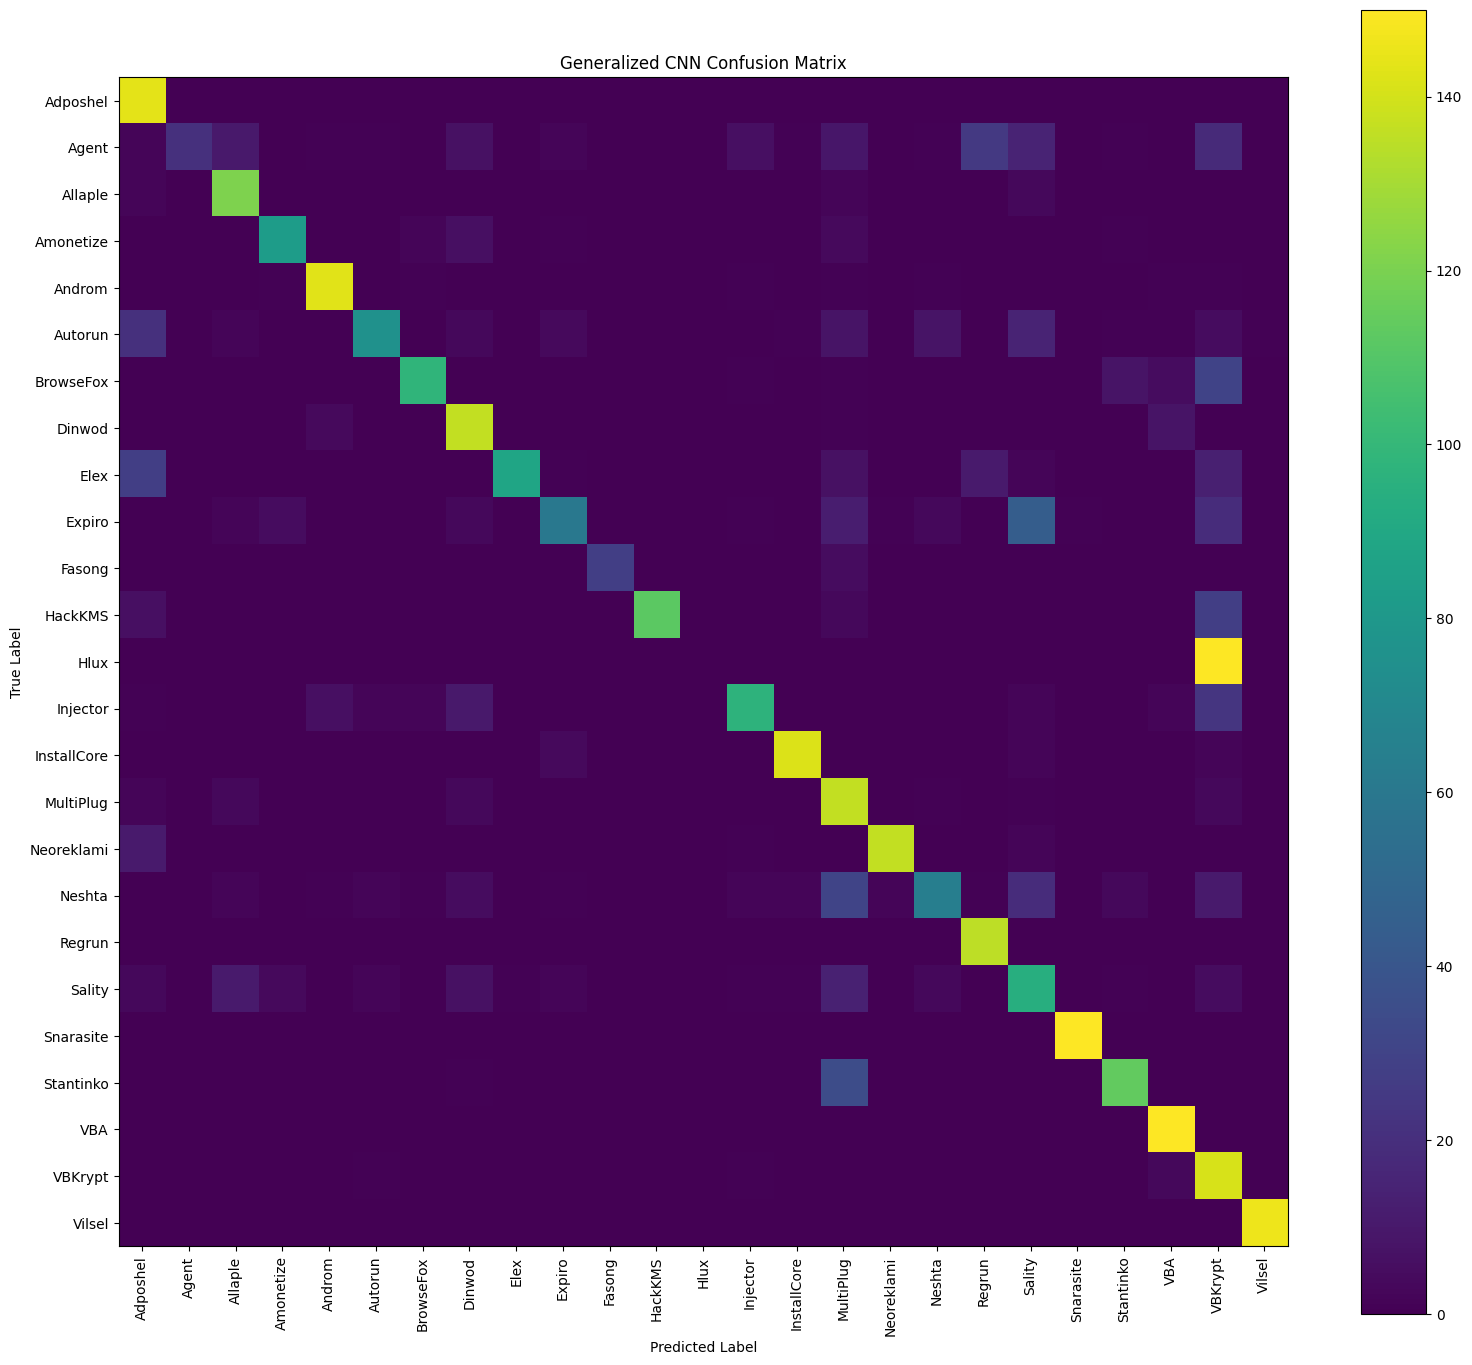

In [83]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(16, 14)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Generalized CNN Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=90
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

plt.tight_layout()

CONFUSION_MATRIX_PATH = (
    OUTPUT_DIR /
    "confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

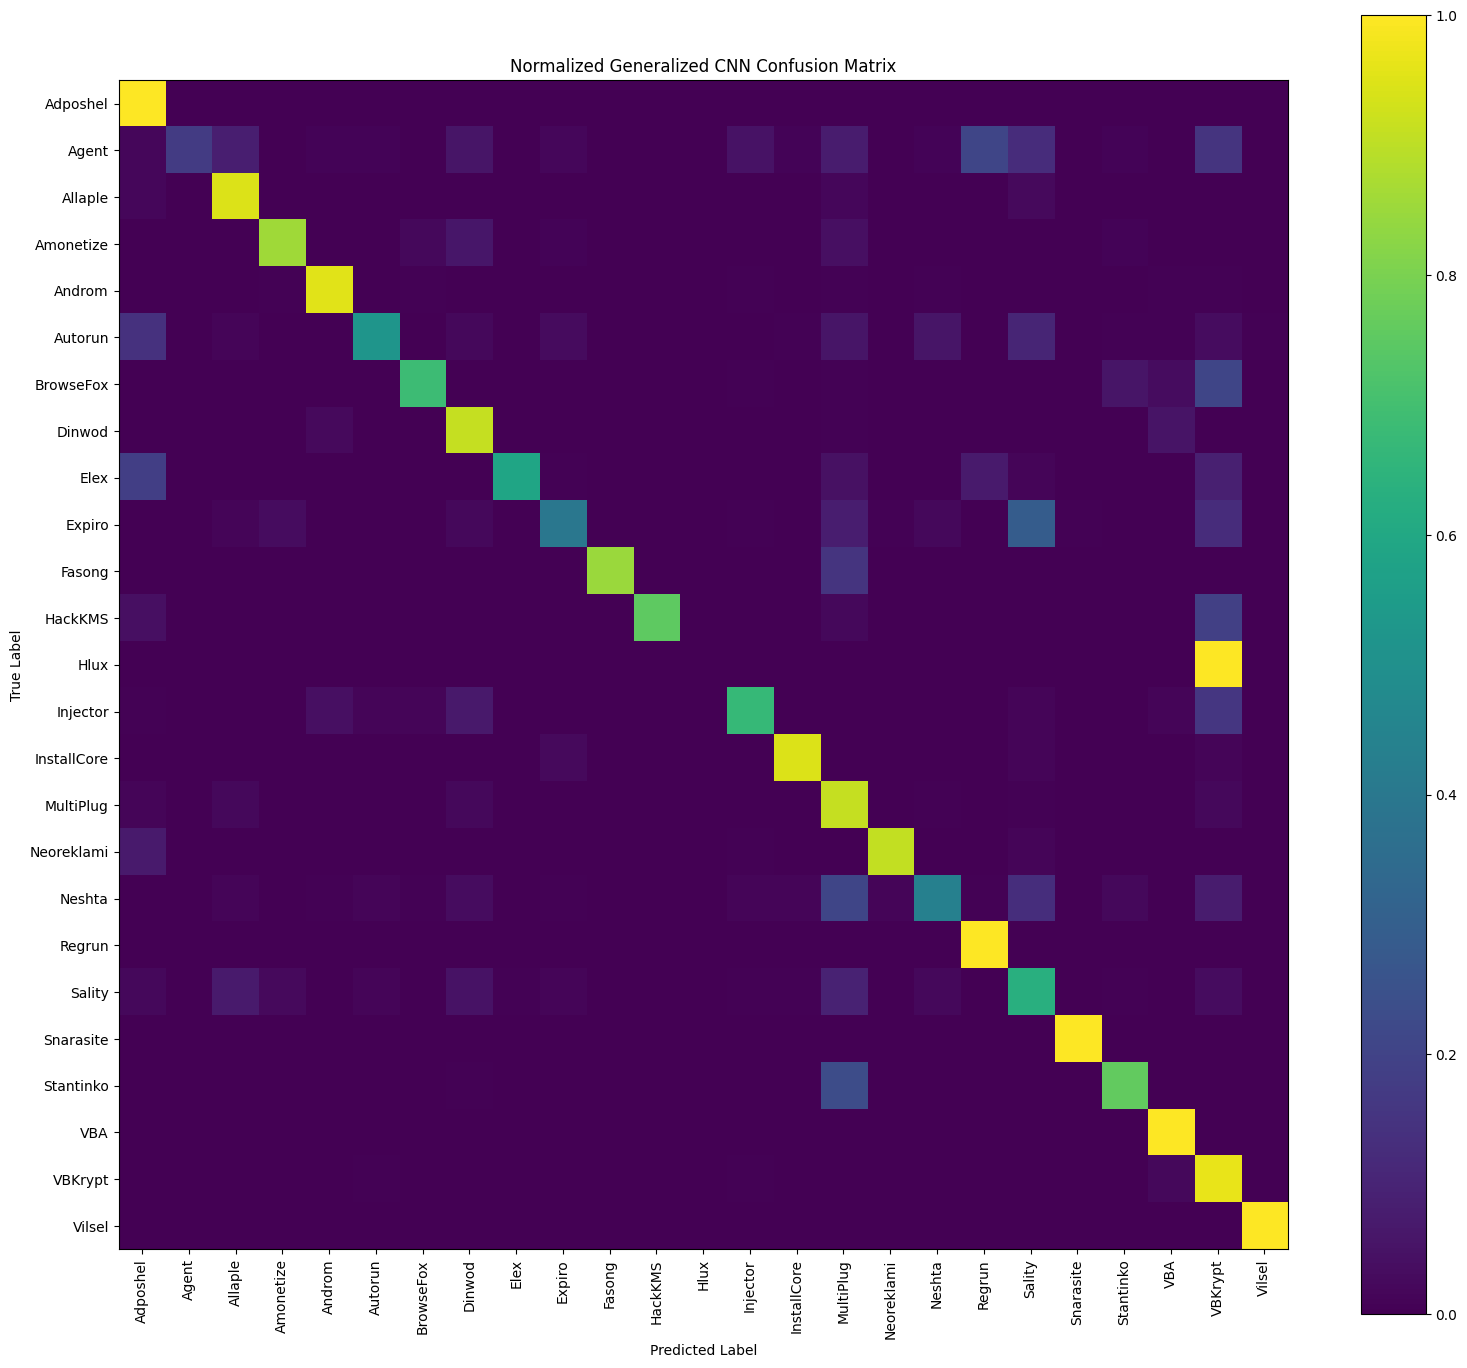

In [84]:
cm_normalized = (
    cm.astype("float") /
    cm.sum(axis=1)[:, np.newaxis]
)

plt.figure(
    figsize=(16, 14)
)

plt.imshow(
    cm_normalized,
    interpolation="nearest",
    vmin=0,
    vmax=1
)

plt.title(
    "Normalized Generalized CNN Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=90
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

plt.tight_layout()

NORMALIZED_CM_PATH = (
    OUTPUT_DIR /
    "normalized_confusion_matrix.png"
)

plt.savefig(
    NORMALIZED_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
class_performance = report_df.loc[
    class_names,
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
].copy()

class_performance = (
    class_performance
    .sort_values(
        "f1-score",
        ascending=False
    )
)

display(class_performance)

,precision,recall,f1-score,support
Snarasite,0.993377,1.000000,0.996678,150.0
Vilsel,0.993197,1.000000,0.996587,146.0
InstallCore,0.965986,0.946667,0.956229,150.0
Neoreklami,0.978417,0.906667,0.941176,150.0
Androm,0.922581,0.953333,0.937705,150.0
VBA,0.882353,1.000000,0.937500,150.0
Fasong,1.000000,0.848485,0.918033,33.0
Regrun,0.784884,1.000000,0.879479,135.0
Amonetize,0.892473,0.855670,0.873684,97.0
Allaple,0.801325,0.945312,0.867384,128.0


In [86]:
CLASS_PERFORMANCE_PATH = (
    OUTPUT_DIR /
    "class_performance.csv"
)

class_performance.to_csv(
    CLASS_PERFORMANCE_PATH
)

print(
    "Class performance saved:",
    CLASS_PERFORMANCE_PATH
)

Class performance saved: /kaggle/working/generalized_cnn_v3_outputs/class_performance.csv


In [87]:
prediction_df = test_df[
    [
        "relative_path",
        "class_name",
        "label_id"
    ]
].copy()

prediction_df["predicted_label_id"] = y_pred

prediction_df["predicted_class"] = [
    class_names[index]
    for index in y_pred
]

prediction_df["correct"] = (
    prediction_df["label_id"]
    ==
    prediction_df["predicted_label_id"]
)

prediction_df[
    "prediction_confidence"
] = np.max(
    y_prob,
    axis=1
)

PREDICTIONS_PATH = (
    OUTPUT_DIR /
    "test_predictions.csv"
)

prediction_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

print(
    "Predictions saved:",
    PREDICTIONS_PATH
)

print(
    "Correct predictions:",
    prediction_df["correct"].sum()
)

print(
    "Incorrect predictions:",
    (~prediction_df["correct"]).sum()
)

Predictions saved: /kaggle/working/generalized_cnn_v3_outputs/test_predictions.csv
Correct predictions: 2615
Incorrect predictions: 862


In [88]:
final_metrics = {
    "model_name": "MaleVis Generalized CNN",
    "best_validation_accuracy": float(
        val_accuracy
    ),
    "best_validation_loss": float(
        val_loss
    ),
    "final_test_accuracy": float(
        test_accuracy
    ),
    "final_test_loss": float(
        test_loss
    ),
    "weighted_precision": float(
        precision
    ),
    "weighted_recall": float(
        recall
    ),
    "weighted_f1_score": float(
        f1_score
    ),
    "number_of_classes": int(
        NUM_CLASSES
    ),
    "training_samples": int(
        len(train_df)
    ),
    "validation_samples": int(
        len(internal_val_df)
    ),
    "test_samples": int(
        len(test_df)
    )
}

METRICS_PATH = (
    OUTPUT_DIR /
    "final_metrics.json"
)

with open(
    METRICS_PATH,
    "w"
) as file:
    json.dump(
        final_metrics,
        file,
        indent=4
    )

print(
    "Final metrics saved:",
    METRICS_PATH
)

Final metrics saved: /kaggle/working/generalized_cnn_v3_outputs/final_metrics.json


In [89]:
FINAL_MODEL_PATH = (
    OUTPUT_DIR /
    "malevis_generalized_cnn_final.keras"
)

best_model.save(
    FINAL_MODEL_PATH
)

print(
    "Final model saved:",
    FINAL_MODEL_PATH
)

Final model saved: /kaggle/working/generalized_cnn_v3_outputs/malevis_generalized_cnn_final.keras


In [90]:
print("Generated files:")

for file_path in sorted(
    OUTPUT_DIR.iterdir()
):
    print(
        "-",
        file_path.name
    )

Generated files:
- best_generalized_cnn.keras
- class_performance.csv
- classification_report.csv
- confusion_matrix.png
- final_metrics.json
- malevis_generalized_cnn_final.keras
- normalized_confusion_matrix.png
- test_predictions.csv
- training_log.csv


## 15. Final Results Summary

The final generalized CNN was evaluated on the internal validation
and untouched final test sets.

The final model achieved stable validation and test performance,
indicating improved generalization compared with its training
performance.

The test set was used only after model selection and tuning were
completed.

In [91]:
print("=" * 45)
print("Final Generalized CNN Results")
print("=" * 45)

print(f"Validation Accuracy : {val_accuracy * 100:.2f}%")
print(f"Validation Loss     : {val_loss:.4f}")

print(f"Test Accuracy       : {test_accuracy * 100:.2f}%")
print(f"Test Loss           : {test_loss:.4f}")

print(f"Weighted Precision  : {precision * 100:.2f}%")
print(f"Weighted Recall     : {recall * 100:.2f}%")
print(f"Weighted F1-score   : {f1_score * 100:.2f}%")

print("=" * 45)

Final Generalized CNN Results
Validation Accuracy : 74.24%
Validation Loss     : 1.0178
Test Accuracy       : 75.21%
Test Loss           : 0.9747
Weighted Precision  : 79.46%
Weighted Recall     : 75.21%
Weighted F1-score   : 73.87%


## 16. Conclusion

A generalized CNN was developed for 25-class MaleVis malware image
classification using the cleaned train, internal validation, and final
test splits.

The model used mild training-only data augmentation, batch
normalization, L2 regularization, dropout, global average pooling, and
validation-based model selection.

The final model achieved approximately 74.24% internal validation
accuracy and 75.21% final test accuracy. The close validation and test
performance suggests that the selected model generalizes consistently
to unseen data.

Some class-level variation remains, as shown by the classification
report and confusion matrices. These results are retained as part of
the final model evaluation.

The final test set was not used for model tuning.

### Final Evaluation Policy

The model architecture and training configuration were finalized using
the training and internal validation splits.

The final test split was evaluated only after model selection was
completed. No further tuning was performed after observing the final
test results.